## PyTorch Red Neuronal de Clasificación

Los problemas de clasificación son aquellos en los que se predice si algo es una cosa o otra, entre estos podemos encontrar:

1. Clasificación Binaria: el objetivo es una de dos cosas, por ejemplo, si o no.
2. Clasificación Multi-Clase: el objetivo puede ser uno o más de dos cosas.
3. Clasificación Multi-Label: al objetivo se le puede asignar una o más de dos opciones.

### Arquitectura de un Modelo de Clasificación

De manera general la arquitectura de una red neuronal de clasificación contiene:

| Hiperparametros | Clasificación Binaria | Clasificación Multi-clase|
|---              |---                    |---                       |
| **Shape de la forma de entrada**| Número de variables | Igual a la clasificación binaria |
| **Capas ocultas** | Problema especifico, mínimo = 1, máximo = ilimitado | Igual a la clasificación binaria |
| **Neuronas por capa oculta** | Problema especifico, generalmente entre 10 a 512 | Igual a la clasificación binaria |
| **Shape de la capa de salida** | 1 (una clase o la otra) | 1 por clase (e.g 3 para comida, personas o fotos de perro) |
| **Activación capa oculta** | Usualmente ReLU pero puede ser otra | Igual a la clasificación binaria |
| **Activación para la salida** | Sigmoid | Softmax |
| **Función de loss** | Binary Crossentropy | Cross entropy |
| **Optimizador**| SGD, Adam o otras opciones | Igual a la clasificación binaria |

### Realizando datos de clasificación

In [1]:
from sklearn.datasets import make_circles

#* Realizando 1000 ejemplos
n_samples = 1000

#* Creamos los círculos
X, y = make_circles(n_samples=n_samples, noise=0.06, factor=0.5, random_state=5)

In [2]:
len(X), len(y)  #* 1000 ejemplos

(1000, 1000)

In [3]:
print(f"Ejemplos de X: {X[:5]}")
print(f"Ejemplos de y: {y[:5]}")

Ejemplos de X: [[ 0.57195573  0.29742632]
 [ 0.54069686  0.10856762]
 [-0.82408679  0.61022482]
 [ 1.11266426  0.07313918]
 [-0.90731993 -0.31737559]]
Ejemplos de y: [1 1 0 0 0]


In [4]:

#* Realizamos un DataFrame de los datos de círculos

import pandas as pd

circles = pd.DataFrame({"X1": X[:, 0], "X2": X[:, 1], "label": y})
print(circles.head())

         X1        X2  label
0  0.571956  0.297426      1
1  0.540697  0.108568      1
2 -0.824087  0.610225      0
3  1.112664  0.073139      0
4 -0.907320 -0.317376      0


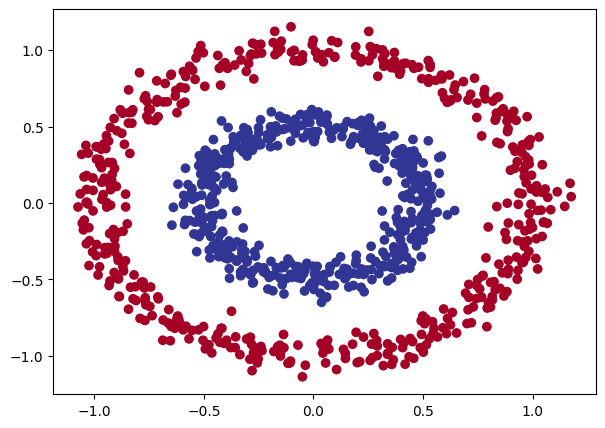

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(circles["X1"], circles["X2"], c=circles["label"], cmap=plt.cm.RdYlBu);

**Nota:** Los datos que estamos trabajando se les dice conjuntos de datos juguete, un conjunto de datos que es los suficientemente pequeño para experimentos pero tiene el tamaño suficiente para practicar los fundamentos.

### Shapes de las entradas y salidas

Uno de los errores más comunes en deep learning son los errores de shape, ya que si hay un mismatching entre los shapes de los tensores y operaciones de tensores resultara en errores para el modelo.

Para solucionar esto es familiarizarnos con las shapes de nuestros datos, por ejemplo con este código tenemos que

In [6]:
print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

Shape de X: (1000, 2)
Shape de y: (1000,)


Tenemos que los datos para $X$ y $y$ son de $1000$ datos, para ver que nos dice la segunda dimensión de $X$ podemos visualizar algunos ejemplos para entender las entradas y salidas de nuestro modelo

In [7]:
print(f"Valor para un ejemplo de X: {X[0]} y lo mismo para y: {y[0]}")
print(f"Shape para un ejemplo de X: {X[0].shape} y lo mismo para y: {y[0].shape}")

Valor para un ejemplo de X: [0.57195573 0.29742632] y lo mismo para y: 1
Shape para un ejemplo de X: (2,) y lo mismo para y: ()


Luego tenemos que la segunda dimensión de $X$ nos dice las variables de los datos mientras que $y$ tiene una sola variable, así, para este ejemplo tenemos dos entradas y una sola salida.

### Convirtiendo los datos en tensores y creación de train y test

In [8]:
import torch
torch.__version__

'2.6.0+cu118'

In [9]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]  #* 5 ejemplos de X y y

(tensor([[ 0.5720,  0.2974],
         [ 0.5407,  0.1086],
         [-0.8241,  0.6102],
         [ 1.1127,  0.0731],
         [-0.9073, -0.3174]]),
 tensor([1., 1., 0., 0., 0.]))

In [10]:
X.dtype, y.dtype  #* Tipo de dato de X y y

(torch.float32, torch.float32)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [12]:
len(X_train), len(X_test), len(y_train), len(y_test)  #* 800, 200, 800, 200 ejemplos

(800, 200, 800, 200)

### Construyendo un Modelo

Vamos a construir un modelo que clasifique nuestros círculos rojos y azules.

Para hacer esto, queremos:
1. Configurar nuestro device agnostic, es decir, si tenemos disponible GPU o CPU.
2. Construcción del modelo usando `nn.Module`.
3. Definimos la función loss y el optimizador.
4. Creamos un training y testing loop.

In [13]:
import torch
from torch import nn

#* Configuración device agnostic
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [14]:

#* Vamos a crear un modelo que:
#* 1. Usa las subclasses de nn.Module
#* 2. 2 nn.linear() capas que son capaces de manejar las dimensiones de nuestros datos.
#* 3. Define un método forward() que contenga nuestro forward pass del modelo.
#* 4. Creamos una instancia de nuestro modelo y lo movemos a la GPU si está disponible.

torch.cuda.manual_seed(42)

#* 1.
class CircleModelV0(nn.Module):
    
    #* 2.
    def __init__(self):
        super().__init__()
        
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=1)
    
    #* 3.
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_2(self.layer_1(x)) #* x -> layer_1 -> layer_2

#* 4.
model_0 = CircleModelV0().to(device)
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.0591, -0.6501],
                      [ 0.0503,  0.5588],
                      [-0.6562,  0.5834],
                      [-0.0819, -0.4828],
                      [ 0.1692, -0.5500],
                      [ 0.4045,  0.2462],
                      [ 0.1765,  0.5778],
                      [-0.2680, -0.2708],
                      [ 0.1428, -0.4155],
                      [ 0.2382,  0.6740]], device='cuda:0')),
             ('layer_1.bias',
              tensor([ 0.3953,  0.1171,  0.3264,  0.4358,  0.1394, -0.0446,  0.6726, -0.5218,
                      -0.1529, -0.5425], device='cuda:0')),
             ('layer_2.weight',
              tensor([[-0.2157,  0.1309,  0.2363,  0.0338, -0.1010,  0.0420, -0.0146, -0.2753,
                       -0.0587, -0.2685]], device='cuda:0')),
             ('layer_2.bias', tensor([0.2109], device='cuda:0'))])

In [15]:

#* Replicamos el modelo usando nn.Sequential, de esta manera podemos crear un modelo de una manera más rápida y sencilla, pero si queremos modelos más complejos usamos la subclass de nn.Module.
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.1718, -0.5640],
                      [ 0.5093,  0.4189],
                      [-0.5466, -0.6107],
                      [ 0.3262, -0.0737],
                      [-0.1303,  0.5065],
                      [-0.6652, -0.6508],
                      [-0.4330, -0.2082],
                      [ 0.3783,  0.2358],
                      [ 0.2978, -0.5498],
                      [ 0.1407,  0.1317]], device='cuda:0')),
             ('0.bias',
              tensor([-0.3389,  0.0804, -0.4540,  0.4503, -0.4374, -0.2821,  0.1487, -0.2126,
                      -0.3024, -0.1738], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.1780, -0.1329, -0.0018, -0.0482, -0.0267,  0.2274,  0.2719, -0.2320,
                       -0.2242,  0.2333]], device='cuda:0')),
             ('1.bias', tensor([0.2314], device='cuda:0'))])

In [16]:

#* Predicciones
with torch.inference_mode():
    untrined_preds = model_0(X_test.to(device))
print(f"Tamaño de predcciones: {len(untrined_preds)}, Shape: {untrined_preds.shape}")
print(f"Tamaño de ejemplos de test: {len(X_test)}, Shape: {X_test.shape}")
print(f"Primeros 10 predicciones:\n {torch.round(untrined_preds[:10])}")
print(f"Primeras 10 labels:\n {y_test[:10]}")

Tamaño de predcciones: 200, Shape: torch.Size([200, 1])
Tamaño de ejemplos de test: 200, Shape: torch.Size([200, 2])
Primeros 10 predicciones:
 tensor([[-0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [-0.],
        [1.],
        [-0.],
        [0.],
        [-0.]], device='cuda:0')
Primeras 10 labels:
 tensor([0., 1., 1., 1., 0., 0., 0., 0., 1., 1.])


In [17]:

#* Configuramos la función de pérdida y el optimizador
#* 1. Usamos Binary Cross Entropy porque es un problema de clasificación binaria
#* La función de pérdida nos dice qué tan bien lo está haciendo nuestro modelo.

#* Para este caso usaremos `torch.nn.BECWithLogitsLoss`

loss_fn = nn.BCEWithLogitsLoss() #* Función de activación Sigmoid

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)


In [18]:

#* Calculamos la precisión del modelo - esto es que porcentaje de predicciones correctas hace el modelo.
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_pred)) * 100
    return acc


### Entrenamos el Modelo

Para entrenar el modelo tenemos que realizar un training loop

1. Forward pass
2. Calcular la pérdida
3. Optimizar zero grad
4. Loss Backward (backpropagation)
5. Paso de optimización

Las salidas de nuestro modelo son logits, vamos a convertir estos logits en probabilidades de predicción pasándolo a traves de una función de activación (por ejemplo, sigmoid para clasificación binaria y softmax para clasificación multi-clase).

Luego convertimos las predicciones de nuestro modelo en predicción de labels usando `round()` o tomando `argmax()`.

Para nuestras valores de probabilidades de predicción, necesitamos definir unos rangos de redondeo:
* `y_pred_probs` >= 0.5, `y=1` (class 1)
* `y_pred_probs` <= 0.5, `y=0` (class 0)

In [19]:
torch.manual_seed(5)
torch.cuda.manual_seed(5)

#* Número de epocas
epochs = 100

#* Movemos los datos a la GPU si está disponible
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

#* Creamos un bucle de entrenamiento y evaluación
for epoch in range(epochs):
    
    #* Modo de entrenamiento
    model_0.train()
    
    #* 1. Forward pass
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) #* convertimos logits -> pred probs -> pred labels
    
    #* 2. Calculamos la pérdida/accuracy
    loss = loss_fn(y_logits, y_train)
    
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
    
    #* 3. Optimización zero grad
    optimizer.zero_grad()
    
    #* 4. Loss backward
    loss.backward()
    
    #* 5. Optimizer step
    optimizer.step()
    
    #* 6. Evaluación
    model_0.eval()
    with torch.inference_mode():
        
        #* 1. Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        #* 3. Calculamos la pérdida/accuracy del test
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)
        
    #* 7. Imprimimos los resultados
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Train Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")


Epoch: 0 | Train Loss: 0.70556 | Train Acc: 58.75% | Test Loss: 0.72152 | Test Acc: 55.50%
Epoch: 10 | Train Loss: 0.70125 | Train Acc: 57.50% | Test Loss: 0.71313 | Test Acc: 55.00%
Epoch: 20 | Train Loss: 0.69863 | Train Acc: 56.12% | Test Loss: 0.70781 | Test Acc: 54.50%
Epoch: 30 | Train Loss: 0.69692 | Train Acc: 55.88% | Test Loss: 0.70426 | Test Acc: 55.00%
Epoch: 40 | Train Loss: 0.69576 | Train Acc: 56.00% | Test Loss: 0.70179 | Test Acc: 55.00%
Epoch: 50 | Train Loss: 0.69497 | Train Acc: 56.25% | Test Loss: 0.70004 | Test Acc: 54.50%
Epoch: 60 | Train Loss: 0.69441 | Train Acc: 56.50% | Test Loss: 0.69877 | Test Acc: 54.50%
Epoch: 70 | Train Loss: 0.69402 | Train Acc: 56.75% | Test Loss: 0.69783 | Test Acc: 54.00%
Epoch: 80 | Train Loss: 0.69374 | Train Acc: 57.63% | Test Loss: 0.69713 | Test Acc: 53.50%
Epoch: 90 | Train Loss: 0.69354 | Train Acc: 59.13% | Test Loss: 0.69661 | Test Acc: 54.00%


### Predicciones y Evaluando el Modelo

Desde las métricas vemos que nuestro modelo no esta aprendiendo nada, vamos a inspeccionar esto realizando algunas predicciones y visualizando los resultados.

Para esto, vamos a importar la función `plot_decision_boundary` - https://github.com/mrdbourke/pytorch-deep-learning/blob/main/helper_functions.py

In [20]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
    print("helper_functions.py ya existe, saltando la descarga")
else:
    print("Descargando helper_functions.py")
    request = requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py')
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)
        
from helper_functions import plot_predictions, plot_decision_boundary



helper_functions.py ya existe, saltando la descarga


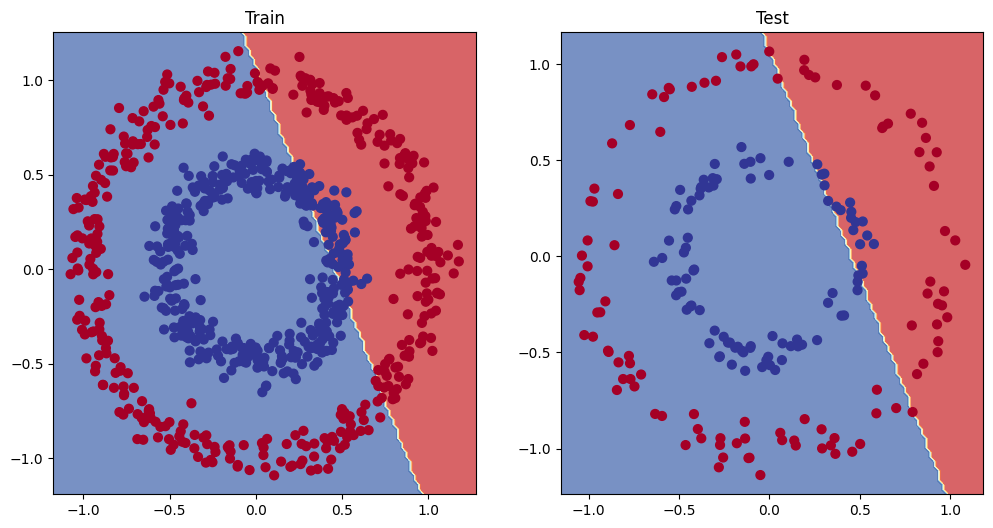

In [21]:

#* Plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)


### Mejorando el Modelo

* Añadiendo más capas ocultas - da al modelo más chances de aprender los patrones del modelo.
* Añadiendo más unidades ocultas.
* Entrenar por más épocas.
* Cambiando la función de activación.
* Cambiando el learning rate.
* Cambiando la función de loss.

Estas opciones son todas desde una perspectiva del modelo porque ellos actúan directamente con el modelo, mejor que los datos.

In [22]:

#* Vamos a mejorar el modelo que tenemos añadiendo más capas,neuronas y más épocas de entrenamiento.

class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.layer_1 = nn.Linear(in_features=2, out_features=15)
        self.layer_2 = nn.Linear(in_features=15, out_features=5)
        self.layer_3 = nn.Linear(in_features=5, out_features=1)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        return self.layer_3(self.layer_2(self.layer_1(x))) #* x -> layer_1 -> layer_2 -> layer_3

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=15, bias=True)
  (layer_2): Linear(in_features=15, out_features=5, bias=True)
  (layer_3): Linear(in_features=5, out_features=1, bias=True)
)

In [23]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [24]:
torch.manual_seed(5)
torch.cuda.manual_seed(5)

#* Número de epocas
epochs = 1000

#* Movemos los datos a la GPU si está disponible
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

#* Creamos un bucle de entrenamiento y evaluación
for epoch in range(epochs):
    
    #* Modo de entrenamiento
    model_1.train()
    
    #* 1. Forward pass
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) #* convertimos logits -> pred probs -> pred labels
    
    #* 2. Calculamos la pérdida/accuracy
    loss = loss_fn(y_logits, y_train)
    
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
    
    #* 3. Optimización zero grad
    optimizer.zero_grad()
    
    #* 4. Loss backward
    loss.backward()
    
    #* 5. Optimizer step
    optimizer.step()
    
    #* 6. Evaluación
    model_1.eval()
    with torch.inference_mode():
        
        #* 1. Forward pass
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        #* 3. Calculamos la pérdida/accuracy del test
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)
        
    #* 7. Imprimimos los resultados
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Train Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")


Epoch: 0 | Train Loss: 0.70891 | Train Acc: 49.12% | Test Loss: 0.69367 | Test Acc: 53.50%
Epoch: 100 | Train Loss: 0.69308 | Train Acc: 65.25% | Test Loss: 0.69452 | Test Acc: 58.50%
Epoch: 200 | Train Loss: 0.69295 | Train Acc: 59.50% | Test Loss: 0.69518 | Test Acc: 54.00%
Epoch: 300 | Train Loss: 0.69294 | Train Acc: 57.88% | Test Loss: 0.69535 | Test Acc: 53.50%
Epoch: 400 | Train Loss: 0.69294 | Train Acc: 57.12% | Test Loss: 0.69537 | Test Acc: 52.50%
Epoch: 500 | Train Loss: 0.69294 | Train Acc: 56.00% | Test Loss: 0.69537 | Test Acc: 51.50%
Epoch: 600 | Train Loss: 0.69294 | Train Acc: 55.38% | Test Loss: 0.69536 | Test Acc: 50.50%
Epoch: 700 | Train Loss: 0.69294 | Train Acc: 54.87% | Test Loss: 0.69535 | Test Acc: 50.50%
Epoch: 800 | Train Loss: 0.69294 | Train Acc: 54.25% | Test Loss: 0.69535 | Test Acc: 50.50%
Epoch: 900 | Train Loss: 0.69294 | Train Acc: 54.12% | Test Loss: 0.69534 | Test Acc: 50.00%


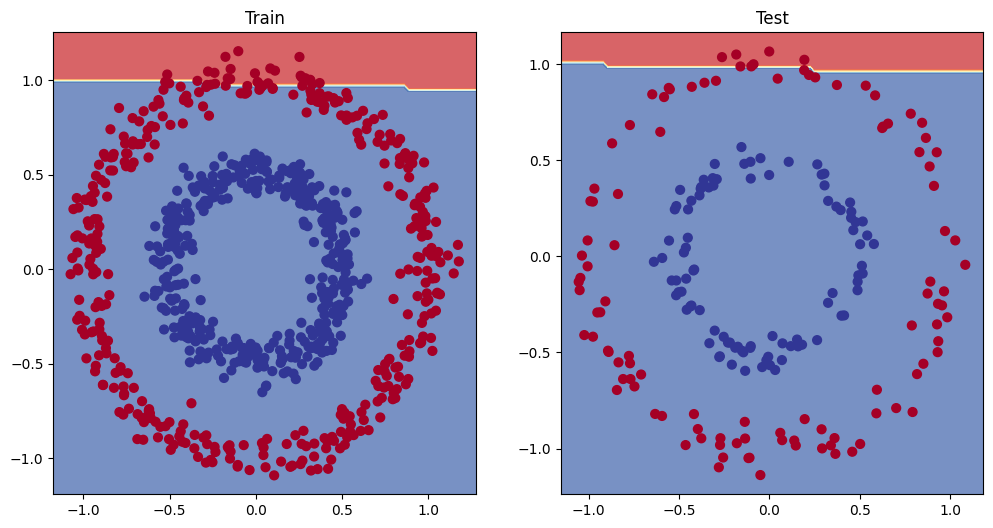

In [25]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

**Nota**: Se debe tener en cuenta la forma de nuestros datos en este caso vemos que para poder clasificar bien los datos necesitamos de funciones no lineales que puedan distinguir bien el patron de los datos.

### Non-linearity

"Que patrones puedes dibujar si te están dando un monto infinito de lineas rectas y no rectas?"

Vamos a recrear unos datos no lineales (Círculos rojos y azules)

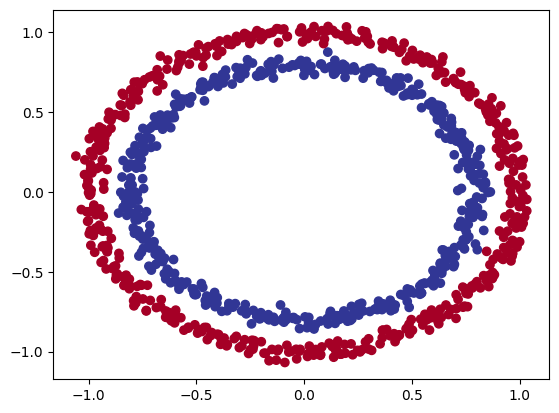

In [26]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples=n_samples, noise=0.03, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu);

In [27]:

#* Convertimos los datos a tensores y luego dividimos en train y test
import torch
from sklearn.model_selection import train_test_split

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

Una función no lineal es un linea curva. Una linea curva is una linea cuyas dirección esta en constante cambio, podemos aplicar distintas funciones no lineales sobre nuestro modelo en pytorch alguna de ella se pueden encontrar en [non-linear activations](https://docs.pytorch.org/docs/stable/nn.html#non-linear-activations-weighted-sum-nonlinearity)

In [28]:

#* Construcción de un modelo no lineal
from torch import nn

class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=15)
        self.layer_2 = nn.Linear(in_features=15, out_features=15)
        self.layer_3 = nn.Linear(in_features=15, out_features=1)
        self.relu = nn.ReLU() # relu es una función de activación no lineal, esta función aplica 0 a los valores negativos y deja los positivos sin cambios.
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
    
model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=15, bias=True)
  (layer_2): Linear(in_features=15, out_features=15, bias=True)
  (layer_3): Linear(in_features=15, out_features=1, bias=True)
  (relu): ReLU()
)

In [29]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(), lr=0.1)

In [30]:
torch.manual_seed(5)
torch.cuda.manual_seed(5)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    
    model_3.train()
    
    #* 1. Forward pass
    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    
    #* 2. Calculamos la perdida/accuracy
    loss = loss_fn(y_logits, y_train)
    accuracy = accuracy_fn(y_train, y_pred)
    
    #* 3. Optimización
    optimizer.zero_grad()
    
    #* 4. Loss Backward
    loss.backward()
    
    #* 5. Paso de optimización
    optimizer.step()
    
    #* Evaluación del modelo
    model_3.eval()
    
    with torch.inference_mode():
        #* 1. Forward pass
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        #* 3. Calculamos la pérdida/accuracy del test
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)
        
    #* Imprimimos los resultados
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Train Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")
    

Epoch: 0 | Train Loss: 0.69539 | Train Acc: 53.87% | Test Loss: 0.68728 | Test Acc: 55.50%
Epoch: 100 | Train Loss: 0.68833 | Train Acc: 53.87% | Test Loss: 0.69119 | Test Acc: 44.50%
Epoch: 200 | Train Loss: 0.68446 | Train Acc: 53.87% | Test Loss: 0.68747 | Test Acc: 54.50%
Epoch: 300 | Train Loss: 0.67852 | Train Acc: 53.87% | Test Loss: 0.68223 | Test Acc: 63.00%
Epoch: 400 | Train Loss: 0.66873 | Train Acc: 53.87% | Test Loss: 0.67359 | Test Acc: 69.50%
Epoch: 500 | Train Loss: 0.65254 | Train Acc: 53.87% | Test Loss: 0.65946 | Test Acc: 72.00%
Epoch: 600 | Train Loss: 0.62482 | Train Acc: 53.87% | Test Loss: 0.63668 | Test Acc: 76.50%
Epoch: 700 | Train Loss: 0.57112 | Train Acc: 53.87% | Test Loss: 0.59131 | Test Acc: 81.50%
Epoch: 800 | Train Loss: 0.47044 | Train Acc: 53.87% | Test Loss: 0.49891 | Test Acc: 90.50%
Epoch: 900 | Train Loss: 0.33082 | Train Acc: 53.87% | Test Loss: 0.35627 | Test Acc: 97.00%


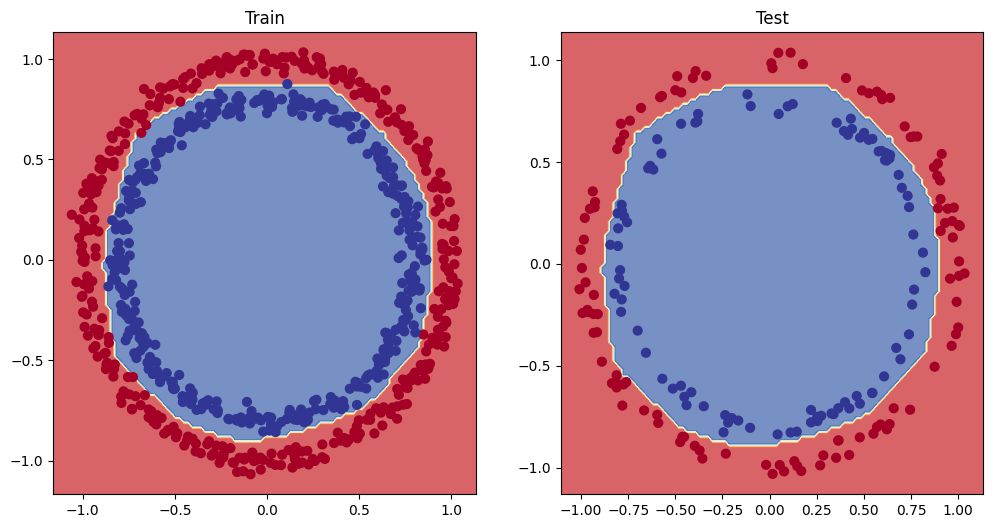

In [31]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

### Evaluando el modelo entrenado con funciones de activación no lineales

In [32]:
model_3.eval()

with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test.to("cpu")))).to(device)
    
y_preds[:10], y_test[:10]  #* 10 ejemplos de predicciones y labels

(tensor([[0.],
         [1.],
         [0.],
         [0.],
         [1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [0.]], device='cuda:0'),
 tensor([0., 1., 0., 0., 1., 1., 1., 1., 1., 0.], device='cuda:0'))

### Replicando las funciones de activación no lineales

Antes vimos como añadiendo funciones no lineales a nuestro modelo nos ayudan a detectar los patrones de mejor manera, pero no sabemos como funcionan realmente.

Vamos a verlos con ejemplos

In [33]:

#* Creamos un tensor
A = torch.arange(-10,10,1, dtype=torch.float32)

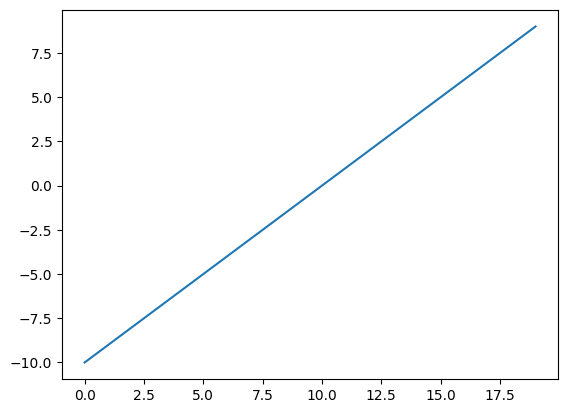

In [34]:

#* Visualizamos el tensor
plt.plot(A);

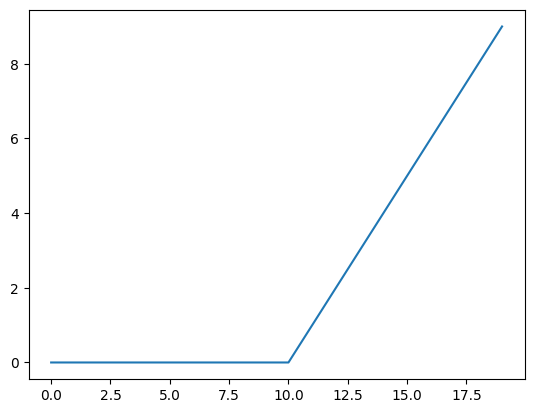

In [35]:

#* Vamos a aplicar la función ReLU
plt.plot(torch.relu(A));

In [36]:

#* Vamos a replicar esta función
def relu(x: torch.Tensor) -> torch.Tensor:
    """
    La función relu devuelve el valor 0 para valores negativos y el valor original para valores positivos
    """
    
    return torch.maximum(torch.tensor(0), x)

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

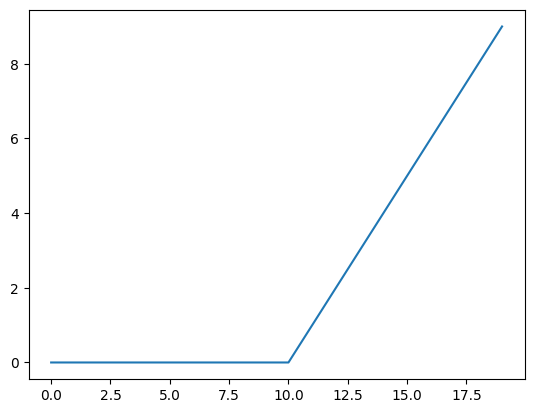

In [37]:
plt.plot(relu(A));

In [38]:

#* Vamos a replicar lo mismo para la función Sigmoid

def sigmoid(x: torch.Tensor) -> torch.Tensor:
    """
    La función sigmoid devuelve un valor entre 0 y 1
    """
    
    return 1 / (1 + torch.exp(-x))

sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

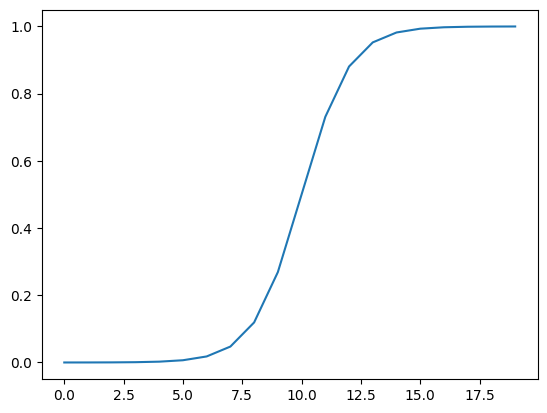

In [39]:
plt.plot(torch.sigmoid(A));

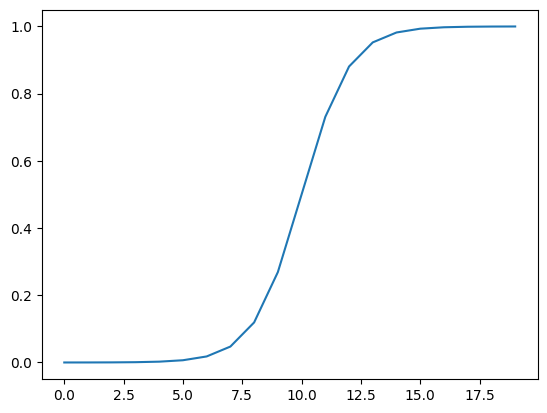

In [40]:

plt.plot(sigmoid(A));

### Colocando todo para un modelo multi-class


Creamos un dataset de juguete para problema de multi-class

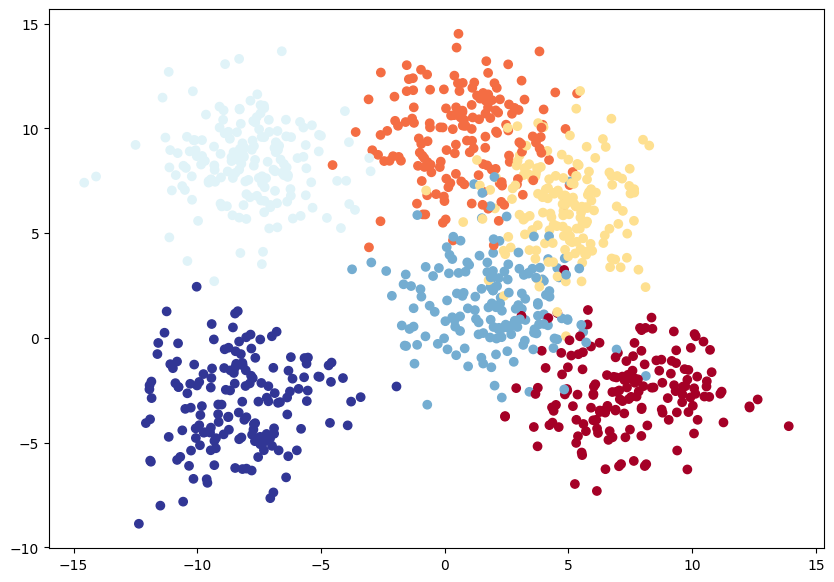

In [41]:
import torch
import matplotlib.pyplot as plt
from torch import nn
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split


NUM_CLASSES = 6
NUM_FEATURES = 2
RANDOM_SEED = 32

#* Creamos los datos
X_blob, y_blob = make_blobs(n_samples=1000, 
                            n_features=NUM_FEATURES, 
                            centers=NUM_CLASSES,
                            cluster_std=2, 
                            random_state=RANDOM_SEED)

#* Convertimos los datos a tensores
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

#* Dividimos los datos en train y test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob, y_blob, test_size=0.2, random_state=RANDOM_SEED)

#* Visualizamos los datos
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu);

In [42]:

#* Creamos el device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [43]:

#* Creamos el modelo multi-class 
class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=10):
        """ 
            Initializa el modelo de clasificación multi-clase.
            
            Args: 
                input_features (int): Número de características de entrada.
                output_features (int): Número de clases de salida.
                hidden_units (int): Número de unidades ocultas entre capas, default 8.
            
            Returns:
        """
        
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features),
        )
    
    def forward(self, x):
        return self.linear_layer_stack(x)
        

#* Creamos una instancia del modelo y enviamos a la GPU si está disponible
model_blob_1 = BlobModel(input_features=2, output_features=6).to(device)

model_blob_1

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=6, bias=True)
  )
)

In [44]:

#* Creamos la función de pérdida y el optimizador
#* Usamos CrossEntropyLoss porque es un problema de clasificación multi-clase
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_blob_1.parameters(), lr=0.1)

Para evaluar nuestro modelo, necesitamos convertir la salida (logtis) a probabilidades de predicción y luego a las etiquetas de predicción.

In [45]:
model_blob_1.eval()
with torch.inference_mode():
    y_logits = model_blob_1(X_blob_test.to(device))

y_logits[:5], y_blob_test[:5]  #* 5 ejemplos de logits y labels

(tensor([[ 3.0051e-01, -8.5636e-01,  1.7820e+00, -1.1665e+00, -3.5723e-01,
          -6.2995e-01],
         [-5.9345e-01, -1.8636e+00,  2.4248e+00, -1.5179e+00, -2.4468e+00,
          -4.1882e-01],
         [-3.5369e-01,  6.5740e-02,  2.8446e-01, -2.0465e-01,  5.6757e-04,
          -3.1300e-01],
         [-1.7887e-01, -4.4787e-02, -6.8149e-03, -1.1339e-01,  2.0444e-01,
          -1.4070e-01],
         [-9.1335e-01, -2.9557e+00,  4.0025e+00, -2.5136e+00, -3.9539e+00,
          -6.6155e-01]], device='cuda:0'),
 tensor([1, 3, 0, 0, 3]))

In [46]:

#* Convertimos los logits de nuestro modelo a probabilidades

y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])  #* 5 ejemplos de probabilidades

tensor([[ 3.0051e-01, -8.5636e-01,  1.7820e+00, -1.1665e+00, -3.5723e-01,
         -6.2995e-01],
        [-5.9345e-01, -1.8636e+00,  2.4248e+00, -1.5179e+00, -2.4468e+00,
         -4.1882e-01],
        [-3.5369e-01,  6.5740e-02,  2.8446e-01, -2.0465e-01,  5.6757e-04,
         -3.1300e-01],
        [-1.7887e-01, -4.4787e-02, -6.8149e-03, -1.1339e-01,  2.0444e-01,
         -1.4070e-01],
        [-9.1335e-01, -2.9557e+00,  4.0025e+00, -2.5136e+00, -3.9539e+00,
         -6.6155e-01]], device='cuda:0')
tensor([[1.4584e-01, 4.5861e-02, 6.4161e-01, 3.3631e-02, 7.5546e-02, 5.7514e-02],
        [4.2589e-02, 1.1959e-02, 8.7116e-01, 1.6898e-02, 6.6742e-03, 5.0716e-02],
        [1.2436e-01, 1.8916e-01, 2.3540e-01, 1.4434e-01, 1.7722e-01, 1.2952e-01],
        [1.4482e-01, 1.6560e-01, 1.7201e-01, 1.5462e-01, 2.1248e-01, 1.5046e-01],
        [7.1889e-03, 9.3257e-04, 9.8084e-01, 1.4511e-03, 3.4367e-04, 9.2473e-03]],
       device='cuda:0')


In [47]:

#* Convertimos las probabilidades a etiquetas
y_pred_labels = torch.argmax(y_pred_probs, dim=1)
y_pred_labels[:5], y_blob_test[:5]  #* 5 ejemplos de probabilidades y etiquetas

(tensor([2, 2, 2, 4, 2], device='cuda:0'), tensor([1, 3, 0, 0, 3]))

In [48]:

#* Creamos training loop y testing loop para el modelo multi-class

torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

#* Número de épocas
epochs = 100

#* Colocamos los datos en la GPU si está disponible
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    #* Modo de entrenamiento
    model_blob_1.train()
    
    #* 1. Forward pass
    y_logits = model_blob_1(X_blob_train)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    
    #* 2. Calculamos la pérdida
    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train, y_pred=y_pred)
    
    #* 3. Optimización
    optimizer.zero_grad()
    
    #* 4. Loss backward
    loss.backward()
    
    optimizer.step()
    
    #* Testing
    model_blob_1.eval()
    with torch.inference_mode():
        #* 1. Forward pass
        test_logits = model_blob_1(X_blob_test)
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        
        #* 2. Calculamos la pérdida
        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_true=y_blob_test, y_pred=test_pred)
    
    #* Imprimimos los resultados
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Train Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Train Loss: 2.48609 | Train Acc: 26.88% | Test Loss: 1.52390 | Test Acc: 39.00%
Epoch: 10 | Train Loss: 1.07782 | Train Acc: 58.38% | Test Loss: 1.08819 | Test Acc: 60.50%
Epoch: 20 | Train Loss: 0.72752 | Train Acc: 68.62% | Test Loss: 0.78802 | Test Acc: 67.50%
Epoch: 30 | Train Loss: 0.58663 | Train Acc: 79.88% | Test Loss: 0.64734 | Test Acc: 80.50%
Epoch: 40 | Train Loss: 0.47448 | Train Acc: 85.38% | Test Loss: 0.53284 | Test Acc: 83.00%
Epoch: 50 | Train Loss: 0.41674 | Train Acc: 86.25% | Test Loss: 0.47307 | Test Acc: 83.50%
Epoch: 60 | Train Loss: 0.38336 | Train Acc: 86.25% | Test Loss: 0.43846 | Test Acc: 83.50%
Epoch: 70 | Train Loss: 0.36092 | Train Acc: 86.88% | Test Loss: 0.41494 | Test Acc: 84.00%
Epoch: 80 | Train Loss: 0.34437 | Train Acc: 87.00% | Test Loss: 0.39764 | Test Acc: 84.50%
Epoch: 90 | Train Loss: 0.33124 | Train Acc: 87.50% | Test Loss: 0.38490 | Test Acc: 87.00%


In [49]:

#* Realizamos y evaluamos predicciones del modelo 
model_blob_1.eval()
with torch.inference_mode():
    y_logits = model_blob_1(X_blob_test)
    
y_logits[:10]

tensor([[ -3.5519,   8.8589,   6.5075,   0.5462,   5.7852, -11.3153],
        [ -6.1284,   1.7362,  -6.2913,   7.3700,   0.9807,   3.6174],
        [  5.9634,  -4.0104,  -1.3486,  -3.0905,   2.0073,  -2.5543],
        [  7.2389,  -4.7520,  -0.4869,  -4.9099,   3.1860,  -4.0463],
        [ -9.5166,   6.2721,  -7.1107,  12.0737,   2.2709,   1.4684],
        [ -3.7333,   9.1652,   6.5096,   0.7852,   5.8972, -11.4580],
        [ -7.5794,   2.8385,  -7.3677,   9.4452,   1.1653,   3.7554],
        [ -7.9222,   5.0530,  -6.0388,   9.9287,   2.0052,   1.3853],
        [ -3.7595,  -2.6176,  -4.1568,   0.7980,   1.0583,   5.1708],
        [  1.1776,   1.2722,   6.7045,  -6.7547,   5.1545,  -8.4704]],
       device='cuda:0')

In [50]:
y_pred_probs = torch.softmax(y_logits, dim=1)
y_pred_probs[:10]  #* 10 ejemplos de probabilidades

tensor([[3.5683e-06, 8.7586e-01, 8.3414e-02, 2.1491e-04, 4.0507e-02, 1.5167e-09],
        [1.3347e-06, 3.4751e-03, 1.1341e-06, 9.7209e-01, 1.6324e-03, 2.2801e-02],
        [9.8023e-01, 4.5685e-05, 6.5429e-04, 1.1462e-04, 1.8761e-02, 1.9596e-04],
        [9.8248e-01, 6.0915e-06, 4.3354e-04, 5.2022e-06, 1.7067e-02, 1.2337e-05],
        [4.1891e-10, 3.0136e-03, 4.6451e-09, 9.9691e-01, 5.5129e-05, 2.4709e-05],
        [2.2569e-06, 9.0206e-01, 6.3376e-02, 2.0695e-04, 3.4353e-02, 9.9696e-10],
        [4.0195e-08, 1.3447e-03, 4.9671e-08, 9.9504e-01, 2.5232e-04, 3.3637e-03],
        [1.7535e-08, 7.5678e-03, 1.1531e-07, 9.9188e-01, 3.5921e-04, 1.9325e-04],
        [1.2851e-04, 4.0258e-04, 8.6375e-05, 1.2253e-02, 1.5895e-02, 9.7123e-01],
        [3.2592e-03, 3.5827e-03, 8.1926e-01, 1.1700e-06, 1.7390e-01, 2.1041e-07]],
       device='cuda:0')

In [51]:
y_pred_labels = torch.argmax(y_pred_probs, dim=1)
y_pred_labels[:10]

tensor([1, 3, 0, 0, 3, 1, 3, 3, 5, 2], device='cuda:0')

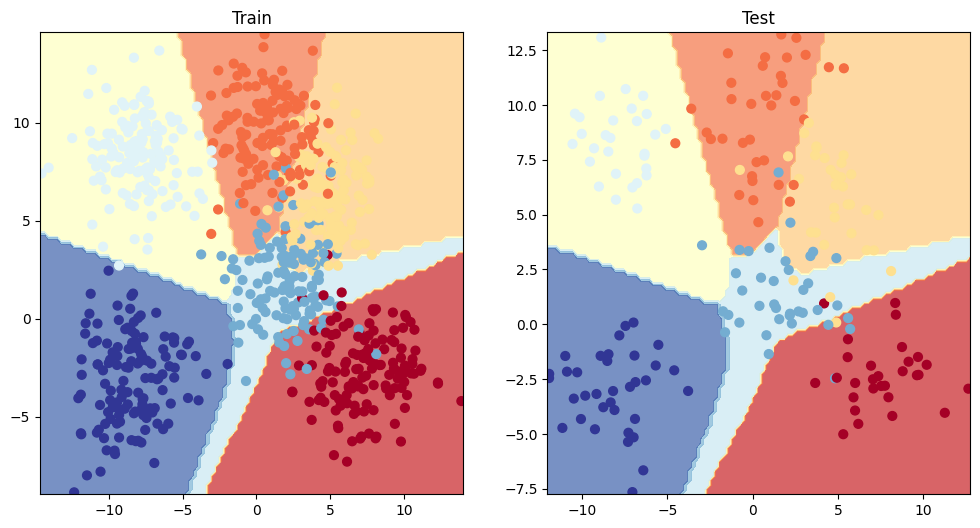

In [52]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_blob_1, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_blob_1, X_blob_test, y_blob_test)
plt.show()

### Métricas de evaluación para modelos de clasificación

| Método / Métrica | Definición | Código |
| ---              |---         |---     |
| Accuracy         |De 100 predicciones, cuantas del modelo son correctas.| `torchmetrics.Accuracy()` o `sklearn.metrics.accuracy_score()`|
| Precision        |Proporción de verdaderos positivos sobre el número de ejemplos. Mayor precision, menos falsos positivos. | `torchmetrics.Precision()` or `sklearn.metrics.precision_score()`|
| Recall           |Proporción de verdaderos positivos sobre el total de falsos positivos y verdaderos positivos. Mayor recall, menos falsos negativos. | `torchmetrics.Recall()` o `sklearn.metrics.recall_score()`|
| F1-score         |Combina la precision y recall en una sola métrica, 1 es mejor, 0 es peor| `torchmetrics.F1Score()` o `sklearn.metrics.f1_score()`|
| Confusion matrix |Compara los valores predichos con los valores verdaderos de manera tabular. Si es 100% todos los valores estarán encima de la diagonal.| `torchmetrics.ConfusionMatrix` o `sklearn.metrics.plot_confusion_matrix()` |
| Reporte de Clasificación | Colección de algunas métricas principales como precision, recall y f1-score | `sklearn.metrics.classification_report()` |

Vamos a visualizar la matrix de confusion

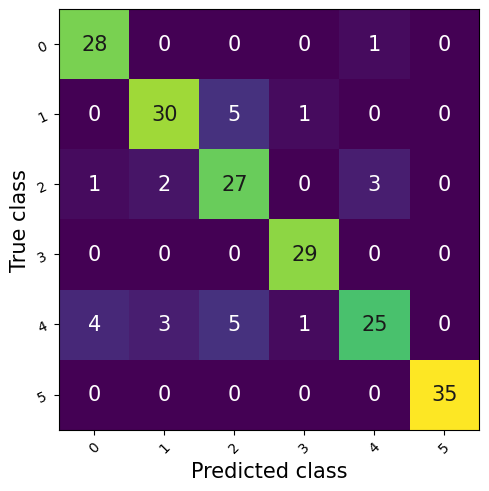

In [53]:
from torchmetrics.classification import MulticlassConfusionMatrix

metric = MulticlassConfusionMatrix(num_classes=NUM_CLASSES).to(device)
metric(y_pred_labels, y_blob_test)
fig_, ax_ = metric.plot()